# Week 3 Day 2 – KNN, Best k, and Model Comparison

## Learning objectives
- Understand KNN intuition and distance-based classification
- See why scaling matters for KNN
- Find a good `k`
- Compare KNN with Decision Tree

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

%matplotlib inline

In [2]:
from pathlib import Path

def find_repo_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd] + list(cwd.parents):
        if (candidate / "requirements.txt").exists() and (candidate / "data").exists():
            return candidate
    return cwd

REPO_ROOT = find_repo_root()
DATASET_PATH = REPO_ROOT / "data" / "week3" / "week3_classification_sample.csv"
DATASET_PATH.parent.mkdir(parents=True, exist_ok=True)


## Load same dataset as Day 1

In [3]:
if DATASET_PATH.exists():
    df = pd.read_csv(DATASET_PATH)
else:
    data = load_breast_cancer()
    df = pd.DataFrame(data.data, columns=data.feature_names)
    df['target'] = data.target
    df.to_csv(DATASET_PATH, index=False)

display(df.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Split data

In [4]:
X = df.drop(columns=['target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(455, 30) (114, 30)


## Scaling for KNN
KNN uses distance, so scaling is important to avoid one feature dominating others.

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## KNN with one fixed k

In [6]:
knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train_scaled, y_train)
y_pred_knn5 = knn5.predict(X_test_scaled)

print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_knn5))
print('Accuracy:', round(accuracy_score(y_test, y_pred_knn5), 3))
print('Precision:', round(precision_score(y_test, y_pred_knn5), 3))
print('Recall:', round(recall_score(y_test, y_pred_knn5), 3))
print('F1:', round(f1_score(y_test, y_pred_knn5), 3))

Confusion Matrix:
 [[39  3]
 [ 2 70]]
Accuracy: 0.956
Precision: 0.959
Recall: 0.972
F1: 0.966


## Compare KNN with and without scaling

In [7]:
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
y_pred_unscaled = knn_unscaled.predict(X_test)

scale_cmp = pd.DataFrame([
    {'Model': 'KNN k=5 (unscaled)', 'Accuracy': accuracy_score(y_test, y_pred_unscaled), 'Precision': precision_score(y_test, y_pred_unscaled), 'Recall': recall_score(y_test, y_pred_unscaled), 'F1': f1_score(y_test, y_pred_unscaled)},
    {'Model': 'KNN k=5 (scaled)', 'Accuracy': accuracy_score(y_test, y_pred_knn5), 'Precision': precision_score(y_test, y_pred_knn5), 'Recall': recall_score(y_test, y_pred_knn5), 'F1': f1_score(y_test, y_pred_knn5)},
])
display(scale_cmp.round(3))

,Model,Accuracy,Precision,Recall,F1
0,KNN k=5 (unscaled),0.912,0.943,0.917,0.930
1,KNN k=5 (scaled),0.956,0.959,0.972,0.966


## Find best k (1 to 30)

In [8]:
rows = []
for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_train_pred = knn.predict(X_train_scaled)
    y_test_pred = knn.predict(X_test_scaled)
    rows.append({
        'k': k,
        'train_accuracy': accuracy_score(y_train, y_train_pred),
        'test_accuracy': accuracy_score(y_test, y_test_pred),
        'test_f1': f1_score(y_test, y_test_pred),
    })

k_df = pd.DataFrame(rows)
display(k_df.head())

,k,train_accuracy,test_accuracy,test_f1
0,1,1.000000,0.938596,0.951049
1,2,0.980220,0.929825,0.942857
2,3,0.978022,0.982456,0.986301
3,4,0.982418,0.947368,0.957746
4,5,0.973626,0.956140,0.965517


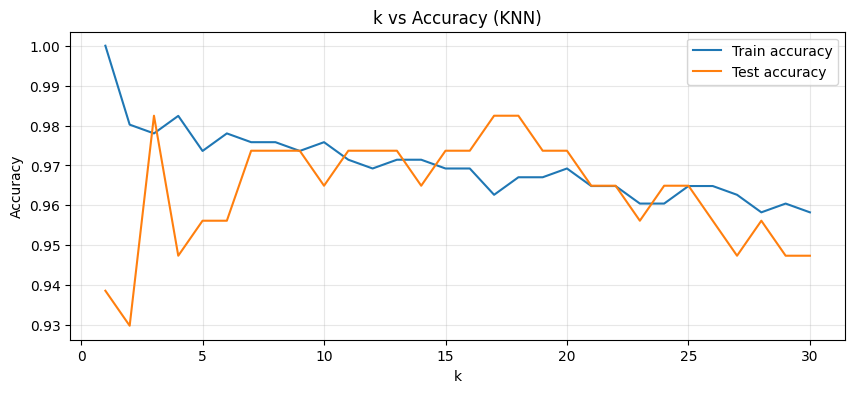

In [9]:
plt.figure(figsize=(10,4))
plt.plot(k_df['k'], k_df['train_accuracy'], label='Train accuracy')
plt.plot(k_df['k'], k_df['test_accuracy'], label='Test accuracy')
plt.title('k vs Accuracy (KNN)')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.legend(); plt.grid(alpha=0.3); plt.show()

Small `k` can overfit. Very large `k` can underfit. We choose `k` that generalizes well on test/CV.

## Optional cross-validation for k selection

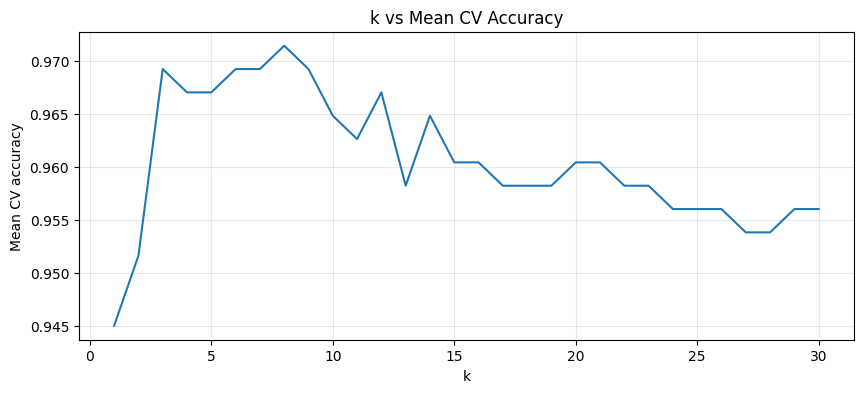

In [10]:
cv_rows = []
for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_rows.append({'k': k, 'cv_mean_accuracy': scores.mean()})
cv_df = pd.DataFrame(cv_rows)

plt.figure(figsize=(10,4))
plt.plot(cv_df['k'], cv_df['cv_mean_accuracy'])
plt.title('k vs Mean CV Accuracy')
plt.xlabel('k')
plt.ylabel('Mean CV accuracy')
plt.grid(alpha=0.3)
plt.show()

## Train best KNN model

In [11]:
best_k = int(cv_df.sort_values('cv_mean_accuracy', ascending=False).iloc[0]['k'])
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)
y_pred_best_knn = best_knn.predict(X_test_scaled)

print('Best k:', best_k)
print('Confusion matrix:\n', confusion_matrix(y_test, y_pred_best_knn))
print('\nClassification report:\n', classification_report(y_test, y_pred_best_knn))

Best k: 8
Confusion matrix:
 [[40  2]
 [ 1 71]]

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        42
           1       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## Compare best KNN with Decision Tree

In [12]:
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

cmp = pd.DataFrame([
    {'Model': f'KNN (k={best_k})', 'Accuracy': accuracy_score(y_test, y_pred_best_knn), 'Precision': precision_score(y_test, y_pred_best_knn), 'Recall': recall_score(y_test, y_pred_best_knn), 'F1': f1_score(y_test, y_pred_best_knn)},
    {'Model': 'Decision Tree (max_depth=4)', 'Accuracy': accuracy_score(y_test, y_pred_tree), 'Precision': precision_score(y_test, y_pred_tree), 'Recall': recall_score(y_test, y_pred_tree), 'F1': f1_score(y_test, y_pred_tree)},
])
display(cmp.round(3))

,Model,Accuracy,Precision,Recall,F1
0,KNN (k=8),0.974,0.973,0.986,0.979
1,Decision Tree (max_depth=4),0.939,0.958,0.944,0.951


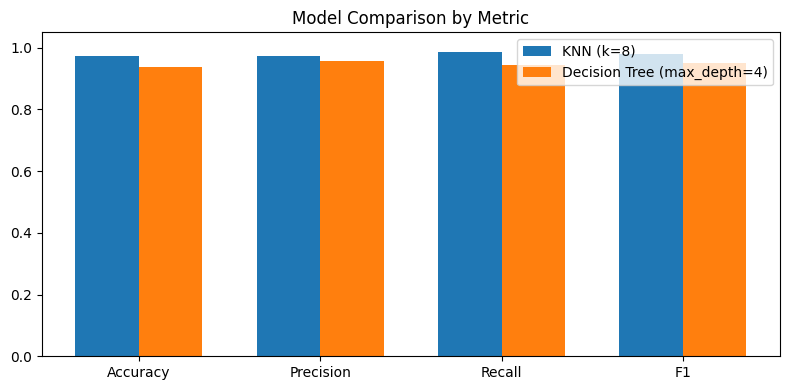

In [13]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,4))
plt.bar(x - width/2, cmp.loc[0, metrics], width, label=cmp.loc[0, 'Model'])
plt.bar(x + width/2, cmp.loc[1, metrics], width, label=cmp.loc[1, 'Model'])
plt.xticks(x, metrics)
plt.ylim(0, 1.05)
plt.title('Model Comparison by Metric')
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation
- Which model has higher recall?
- Which has higher precision?
- Which errors are more important in this task?

## Student tasks
1. Try `metric='manhattan'` in KNN.
2. Compare with Euclidean metric.
3. Test another `k`.
4. Explain whether KNN or Decision Tree is easier to interpret.

In [14]:
print('Week 3 Day 2 KNN and Model Comparison completed successfully.')

Week 3 Day 2 KNN and Model Comparison completed successfully.
